In [7]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from lowRank.NMLRSSE_forwardEuler import NMLRSSE_forwardEuler
from lowRank import compute_expectation as ce
from utils.noise_generator import ColoredNoiseGenerator_Cholesky
from utils import multi_index

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

# spin-boson model parameters
eps = [0, Delta, 2*Delta]
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = [Delta*sx + e*sz for e in eps]
L = sz

In [ ]:
# parameters for the simulation
tmax = 5.0 / Delta
N_steps = 400
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 1000
rank = 8
# hierarchy truncation (total order cutoff for the multi-index set)
# set smaller than N_steps to avoid combinatorial blow-up when rank grows
max_order = 6
parallel_traj = True

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for idx in range(3):
    NMLRSSE_solver = NMLRSSE_forwardEuler(
        Hs = Hs[idx],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = N_steps,
        rank = rank,
        max_order = max_order,
    )
    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    sigma_z = ce.compute_expectation_value(psis, sz)
    axes[idx].plot(NMLRSSE_solver.t_grid, sigma_z, label='rank = {}'.format(rank))
    data = np.load("ref_spinboson/eps_{}.npz".format(eps[idx]))
    tgrid = data['t']
    sigmaz = data['sz']
    axes[idx].plot(tgrid, sigmaz, label='QuAPI')
    axes[idx].set_xlabel('t')
    axes[idx].set_ylabel(r'$\langle \sigma_z \rangle$')
    axes[idx].set_title(r'$\epsilon$={}'.format(eps[idx]))
    axes[idx].grid()
    axes[idx].legend()

plt.suptitle('N_traj={}, max_order={}, N_steps={}'.format(N_traj, max_order, N_steps))
plt.tight_layout()
plt.show()

### Convergence Test

#### expectation over O and then test

In [ ]:
# parameters for the simulation
base = 50
tmax = 5.0 / Delta
N_steps = np.array([1, 2, 4, 8]) * base
ref_N_steps = 800
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 10000
rank = 4
# hierarchy truncation (total order cutoff for the multi-index set)
# set smaller than N_steps to avoid combinatorial blow-up when rank grows
max_order = 10
parallel_traj = True

tgrid_ref = np.linspace(0, tmax, ref_N_steps+1)
C_ref = np.empty((ref_N_steps+1, ref_N_steps+1), dtype=complex)
for i in range(ref_N_steps+1):
    for j in range(ref_N_steps+1):
        C_ref[i, j] = bath_corr(tgrid_ref[i] - tgrid_ref[j])
U, S, V = np.linalg.svd(C_ref)
Ur = U[:, :rank]
Sr = S[:rank]
Vr = V[:rank, :]

NMLRSSE_solver = NMLRSSE_forwardEuler(
    Hs = Hs[0],
    L = L,
    bath_corr = bath_corr,
    tmax = tmax,
    N_steps = ref_N_steps,
    rank = rank,
    max_order = max_order,
    do_low_rank_decomposition=False,
)
NMLRSSE_solver.set_SVD(Sr, Ur, Vr)
psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
ref = ce.compute_expectation_value(psis, sz)
ref = np.array([ref[s] for s in range(0, ref_N_steps+1, ref_N_steps//base)])

error_L2 = []
error_Linf = []
error_end = []
for steps in N_steps:
    NMLRSSE_solver = NMLRSSE_forwardEuler(
        Hs = Hs[0],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = steps,
        rank = rank,
        max_order = max_order,
        do_low_rank_decomposition=False,
    )
    ds = ref_N_steps // steps
    NMLRSSE_solver.set_SVD(Sr, Ur[::ds, :], Vr[:, ::ds])

    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    sigma_z = ce.compute_expectation_value(psis, sz)
    sigma_z_interp = np.array([sigma_z[s] for s in range(0, steps+1, steps // base)])

    # data = np.load("ref_spinboson/eps_{}.npz".format(0))
    # ref = data['sz']

    err_L2 = np.linalg.norm(ref - sigma_z_interp) * np.sqrt(tmax/base)
    err_Linf = np.linalg.norm(ref - sigma_z_interp, ord=np.inf)
    err_end = np.abs(ref[-1] - sigma_z_interp[-1])
    error_L2.append(err_L2)
    error_Linf.append(err_Linf)
    error_end.append(err_end)
    
h = tmax/np.array(N_steps)
c_ref = 0.1
ref_line = c_ref * h
plt.loglog(h, ref_line, '--', label='Order 1 ref')
plt.loglog(tmax/np.array(N_steps), error_L2, marker='o', label=r'$L_2$')
plt.loglog(tmax/np.array(N_steps), error_Linf, marker='s', label=r'$L_{\infty}$')
plt.loglog(tmax/np.array(N_steps), error_end, marker='^', label=r'Error at $t_{max}$')
plt.xlabel('dt')
plt.ylabel('Error')
plt.gca().invert_xaxis()
plt.title(r'$\epsilon$={}, max_order={}, N_traj={}'.format(eps[0], max_order, N_traj))
plt.legend()
plt.show()

#### Strong and weak convergence test

Trajectories: 100%|██████████| 1000/1000 [00:17<00:00, 56.36it/s]


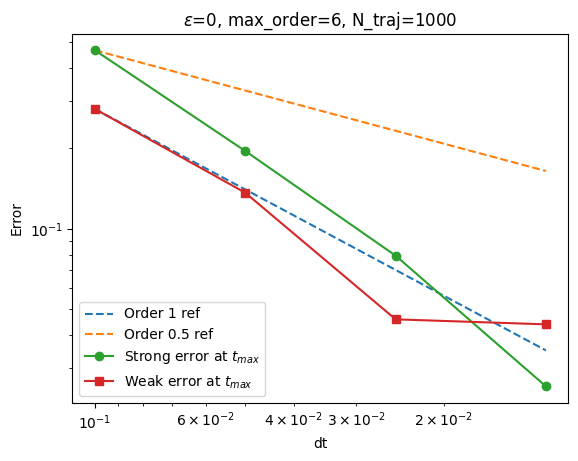

In [11]:
# parameters for the simulation
base = 50
tmax = 5.0 / Delta
N_steps = np.array([1, 2, 4, 8]) * base
ref_N_steps = 800
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 1000
rank = 8
# hierarchy truncation (total order cutoff for the multi-index set)
# set smaller than N_steps to avoid combinatorial blow-up when rank grows
max_order = 6
parallel_traj = True

# generate noise trajectories for strong error
Z = np.empty((N_traj, ref_N_steps), dtype=np.complex128)
noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, tmax, ref_N_steps)
for traj in range(N_traj):
    z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
    Z[traj, :] = z[: ref_N_steps]
ds = [ref_N_steps // steps for steps in N_steps]
Z_interp = [Z[:, ::ds[i]] for i in range(len(N_steps))]


tgrid_ref = np.linspace(0, tmax, ref_N_steps+1)
C_ref = np.empty((ref_N_steps+1, ref_N_steps+1), dtype=complex)
for i in range(ref_N_steps+1):
    for j in range(ref_N_steps+1):
        C_ref[i, j] = bath_corr(tgrid_ref[i] - tgrid_ref[j])
U, S, V = np.linalg.svd(C_ref)
Ur = U[:, :rank]
Sr = S[:rank]
Vr = V[:rank, :]

NMLRSSE_solver = NMLRSSE_forwardEuler(
    Hs = Hs[0],
    L = L,
    bath_corr = bath_corr,
    tmax = tmax,
    N_steps = ref_N_steps,
    rank = rank,
    max_order = max_order,
    do_low_rank_decomposition=False,
    noise_sample_Z = Z,
)
NMLRSSE_solver.set_SVD(Sr, Ur, Vr)
ref_psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
ref_psi_end = ref_psis[:, -1, :]
ref_psi_end_ex = np.sum(ref_psi_end, axis=0) / N_traj
# ref = ce.compute_expectation_value(ref_psis, sz)
# ref = np.array([ref[s] for s in range(0, ref_N_steps+1, ref_N_steps//base)])

strong_error_end = []
weak_error_end = []
for steps in N_steps:
    NMLRSSE_solver = NMLRSSE_forwardEuler(
        Hs = Hs[0],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = steps,
        rank = rank,
        max_order = max_order,
        do_low_rank_decomposition=False,
        noise_sample_Z = Z_interp[N_steps.tolist().index(steps)],
    )
    ds = ref_N_steps // steps
    NMLRSSE_solver.set_SVD(Sr, Ur[::ds, :], Vr[:, ::ds])
    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    # sigma_z = ce.compute_expectation_value(psis, sz)
    # sigma_z_interp = np.array([sigma_z[s] for s in range(0, steps+1, steps // base)])
    psi_end = psis[:, -1, :]
    strong_err_end = np.sum(np.linalg.norm(psi_end - ref_psi_end, axis=1)) / N_traj
    strong_error_end.append(strong_err_end)

    NMLRSSE_solver = NMLRSSE_forwardEuler(
        Hs = Hs[0],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = steps,
        rank = rank,
        max_order = max_order,
        do_low_rank_decomposition=False,
    )
    ds = ref_N_steps // steps
    NMLRSSE_solver.set_SVD(Sr, Ur[::ds, :], Vr[:, ::ds])
    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    psi_end = psis[:, -1, :]
    weak_err_end = np.linalg.norm(np.sum(psi_end, axis=0) / N_traj - ref_psi_end_ex)
    weak_error_end.append(weak_err_end)

h = tmax/np.array(N_steps)
c_ref = weak_error_end[0] / h[0]
ref_line = c_ref * h
plt.loglog(h, ref_line, '--', label='Order 1 ref')
c_ref = strong_error_end[0] / np.sqrt(h[0])
ref_line = c_ref * np.sqrt(h)
plt.loglog(h, ref_line, '--', label='Order 0.5 ref')
plt.loglog(h, strong_error_end, marker='o', label=r'Strong error at $t_{max}$')
plt.loglog(h, weak_error_end, marker='s', label=r'Weak error at $t_{max}$')
plt.xlabel('dt')
plt.ylabel('Error')
plt.gca().invert_xaxis()
plt.title(r'$\epsilon$={}, max_order={}, N_traj={}'.format(eps[0], max_order, N_traj))
plt.legend()
plt.show()